In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
from collections import defaultdict
from datasets import load_dataset
import re, json

In [140]:
try:
    df = pd.read_csv("datasets/raw/goud_articles.csv")
    df.head()
except Exception  as e:
    print(f"Error {e}")

In [141]:
df = df.drop(["url", "published_time", "modified_time"], axis=1)

In [142]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 8241
Total Features (columns): 3


In [143]:
print(df.dtypes)

title       str
category    str
content     str
dtype: object


In [144]:
#Check for Duplicate Values
duplicate_count = len(df[df.duplicated()])
if (duplicate_count > 0):
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
else:
    print("No duplicate values detected in the data.")

2 Duplicate values found in the data.


In [145]:
#Check null values
missing = df.isnull().sum()
print("Missing Values : ", missing[missing > 0])

Missing Values :  content    7
dtype: int64


In [146]:
df.dropna(inplace=True)

In [147]:
df["category"].unique()

<ArrowStringArray>
[       'آش واقع',       'كود سبور', 'جورنالات بلادي',   'ميديا وثقافة',
       'الرئيسية',         'تبركيك',           'آراء',       'كود-تيفي',
 'الزين والحداكة',      'راس السوق',            'كود']
Length: 11, dtype: str

In [148]:
df["category"].value_counts()

category
آش واقع           4116
كود سبور          1331
جورنالات بلادي     935
تبركيك             750
الرئيسية           335
ميديا وثقافة       326
آراء               293
كود-تيفي           110
الزين والحداكة      30
راس السوق            5
كود                  1
Name: count, dtype: int64

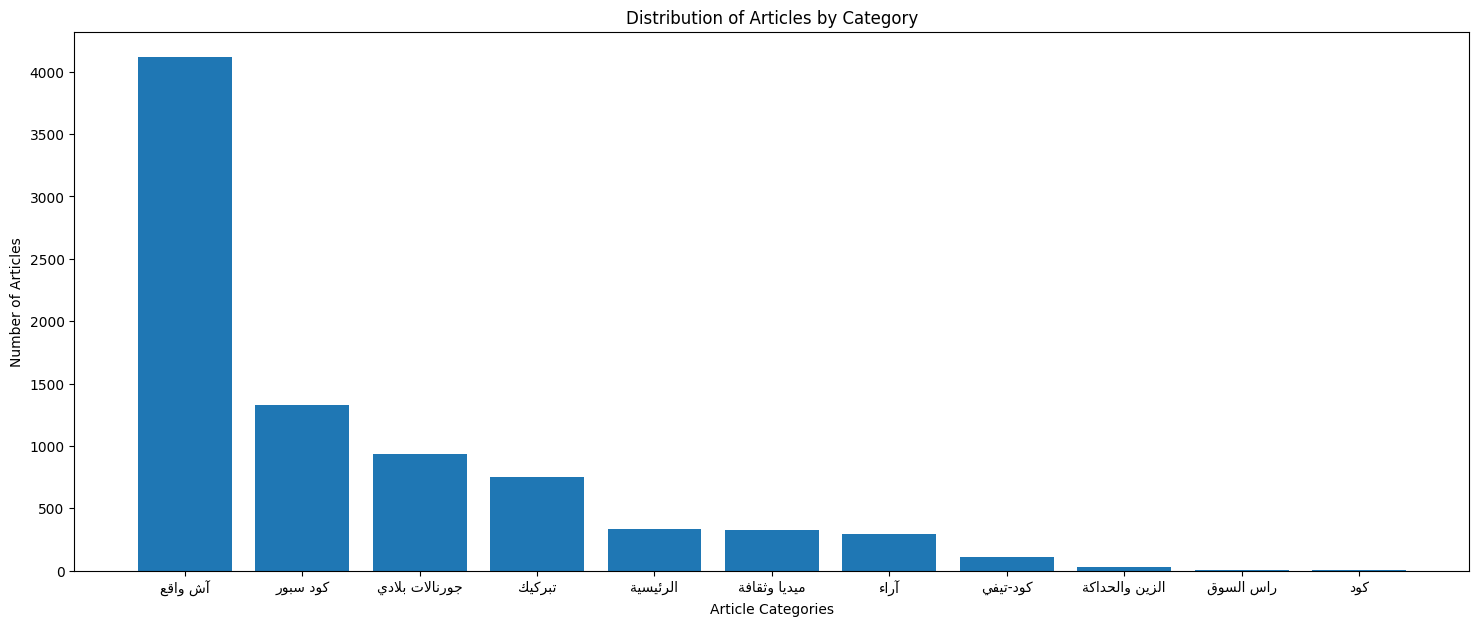

In [149]:
categories_count = df["category"].value_counts()
categories = categories_count.keys().to_list()

for i, category in enumerate(categories):
    categories[i] = get_display(arabic_reshaper.reshape(category))

plt.figure(figsize=(18, 7))
plt.bar(categories, categories_count.values)
plt.title("Distribution of Articles by Category")
plt.xlabel("Article Categories")
plt.ylabel("Number of Articles")
plt.show()

In [150]:
def clean_first_line(text):
    lines = text.split('\n')
    if '/' in lines[0]:
        return '\n'.join(lines[1:]).strip()
    return text

original = df["content"].copy()
df["content"] = df["content"].apply(clean_first_line)

counter = (df["content"] != original).sum()
print(f"Cleaned: {counter}")

Cleaned: 8205


In [151]:
print(f"Empty strings: {(df['content'] == '').sum()}")

Empty strings: 8


In [152]:
df = df[df["content"].str.strip() != ""]

In [153]:
def get_first_paragraph(text, min_words=15):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    
    result = ""
    word_count = 0

    for line in lines:
        result += " " + line
        word_count += len(line.split())
        if word_count >= min_words:
            break

    return result.strip()

In [154]:
df["first_paragraph"] = df["content"].apply(get_first_paragraph)

In [155]:
for i in range(5):
    print(df["first_paragraph"].iloc[i])
    print("_____________" * 10)

أشر المدير العام للأمن الوطني، عبد اللطيف حموشي، ظهر اليوم الأربعاء، على قائمة جديدة تتضمن تعيين 24 مسؤولا جديدا في مناصب المسؤولية للتدبير الإداري والعملياتي للمصالح المركزية والجهوية للأمن الوطني.
__________________________________________________________________________________________________________________________________
أعرب وزير الشؤون الخارجية الاسباني، خوسي مانويل ألباريس، اليوم الجمعة، عن احترام حكومة بلاده لقرار محكمة العدل الأوروبية المتعلق باتفاقيتي الفلاحة والصيد البحري بين الاتحاد الأوروبي والمغرب، مدافعا في نفس الوقت عن “الشراكة الاستراتيجية” مع المملكة المغربية ومؤكدا إرادة الحفاظ عليها.
__________________________________________________________________________________________________________________________________
حددت العصبة الوطنية لكرة القدم الاحترافية، مواعيد الماتشات المؤجلة عن الجولتين 17 و 18 و 19 بالنسبة للفرق اللي مشاركة فالمسابقات الافريقية.
___________________________________________________________________________________________________________________

In [156]:
def count_chars(text):
    return len(str(text).strip())

def count_words(text):
    return len(str(text).strip().split())

def has_code_switching(text):
    text = str(text)
    has_arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    has_latin  = bool(re.search(r'[a-zA-Z]{2,}', text))
    return int(has_arabic and has_latin)

def has_date(text):
    pattern = (
        r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}'
        r'|\d{1,2}\s*(?:نونبر|أكتوبر|يناير|فبراير|مارس|أبريل|ماي|يونيو|يوليوز|غشت|شتنبر|دجنبر)(?:\s*\d{4})?'
        r'|(?:الاثنين|الثلاثاء|الأربعاء|الخميس|الجمعة|السبت|الأحد)\s+\d{1,2}\s*(?:نونبر|أكتوبر|يناير|فبراير|مارس|أبريل|ماي|يونيو|يوليوز|غشت|شتنبر|دجنبر)(?:\s*\d{4})?'
    )
    return int(bool(re.search(pattern, str(text))))

def has_person(text, names):
    return int(any(name in str(text) for name in names))

def has_city(text, locations):
    return int(any(loc in str(text) for loc in locations))

In [157]:
PATTERNS = {
    "urls":               r'http[s]?://\S+|www\.\S+',
    "emails":             r'[\w.+-]+@[\w-]+\.[a-z]{2,}',
    "emojis":             r'[\U00010000-\U0010ffff]|[\u2600-\u27BF]|[\uFE00-\uFE0F]',
    "arabic_punctuation": r'[،؛؟٪٫٬]',
    "latin_punctuation":  r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]',
    "arabic_numbers":     r'[٠-٩]+',
    "latin_numbers":      r'\d+',
    "dates":              r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{1,2}\s*(?:نونبر|أكتوبر|يناير|فبراير|مارس|أبريل|ماي|يونيو|يوليوز|غشت|شتنبر|دجنبر)(?:\s*\d{4})?|(?:الاثنين|الثلاثاء|الأربعاء|الخميس|الجمعة|السبت|الأحد)\s+\d{1,2}\s*(?:نونبر|أكتوبر|يناير|فبراير|مارس|أبريل|ماي|يونيو|يوليوز|غشت|شتنبر|دجنبر)(?:\s*\d{4})?',
    "latin_words":        r'\b[a-zA-Z]{2,}\b',
    "invisible_chars":    r'[\u200e\u200f\u200b\u202a-\u202e\ufeff]',
    "hashtags":           r'#\w+',
    "mentions":           r'@\w+',
    "phone_numbers":      r'(?:\+212|0)[5-7]\d{8}',
    "extra_spaces":       r' {2,}',
    "newlines":           r'\n+',
    "repeated_chars":     r'(.)\1{2,}',
}

def extract_global_patterns(df, column="first_paragraph"):
    features = defaultdict(set)

    for text in df[column].dropna().astype(str):
        for name, pattern in PATTERNS.items():
            matches = [m.group() for m in re.finditer(pattern, text, flags=re.IGNORECASE)]
            features[name].update(matches)

        if has_code_switching(text):
            features["code_switching"].add(text[:80])

    return dict(features)


features = extract_global_patterns(df)

for key, values in features.items():
    print(f"\n[{key}] — {len(values)} found")
    preview = list(values)
    print(preview if preview else "Nothing")


[urls] — 2 found
['https://www.facebook.com/watch/?mibextid=WC7FNe&share_url=https%3A%2F%2Fwww.facebook.com%2Fshare%2Fv%2F19bC9LQVRy%2F%3Fmibextid%3DWC7FNe&v=599937695712500&rdid=jWUbt0BpbYbNOMNM', 'https://web.facebook.com/Goudmediaa/videos/1057250823048478']

[emails] — 0 found
Nothing

[emojis] — 0 found
Nothing

[arabic_punctuation] — 6 found
['٫', '؛', '٬', '؟', '،', '٪']

[latin_punctuation] — 16 found
['%', ')', '?', ':', '_', '!', '&', ',', '=', '(', '|', '.', '/', '-', '+', '@']

[arabic_numbers] — 0 found
Nothing

[latin_numbers] — 489 found
['111', '183', '73', '1966', '156', '7', '930', '00', '2021', '14', '1976', '1200', '2006', '2975', '103', '152', '1947', '1991', '619', '242', '509', '501', '87', '1781', '1915', '5895', '250', '79', '21', '365', '329', '565', '1992', '817', '941', '3781', '67', '375', '49', '967', '399', '461', '120', '2744', '60000', '53', '81', '2430', '2900', '716', '56', '80', '1956', '4', '93622', '505', '160', '2241', '09', '1967', '48', '12', '2

In [158]:
def clean_darija_text(text):
    text = str(text)
    
    # 1. Invisible characters
    text = re.sub(r'[\u200e\u200f\u200b\u202a-\u202e\ufeff]', '', text)
    # 2. URLs
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    # 3. Mentions & hashtags
    text = re.sub(r'[@#]\w+', '', text)
    # 4. Tatweel (ـ) — decorative stretching, no linguistic value
    text = re.sub(r'ـ+', '', text)
    # 5. Non-breaking spaces → regular space
    text = re.sub(r'\xa0+', ' ', text)
    # 6. Repeated letters (arabic) → keep 1
    text = re.sub(r'([\u0600-\u06FF])\1{2,}', r'\1', text)
    # 7. Repeated punctuation → keep 1
    text = re.sub(r'([!؟،.؛])\1+', r'\1', text)
    # 8. Multiple newlines → single newline
    text = re.sub(r'\n{2,}', '\n', text)
    # 9. Multiple spaces → single space
    text = re.sub(r' {2,}', ' ', text)
    # 10. Strip
    text = text.strip()
    
    return text

df["first_paragraph"] = df["first_paragraph"].apply(clean_darija_text)

In [159]:
df["char_count"]      = df["first_paragraph"].apply(count_chars)
df["word_count"]      = df["first_paragraph"].apply(count_words)
df["code_switching"]  = df["first_paragraph"].apply(has_code_switching)
df["has_date"]        = df["first_paragraph"].apply(has_date)

In [160]:
df.head(10)

,title,category,content,first_paragraph,char_count,word_count,code_switching,has_date
0,استعدادا للمونديال.. حموشي عين مسؤولين أمنيين ...,آش واقع,أشر المدير العام للأمن الوطني، عبد اللطيف حموش...,أشر المدير العام للأمن الوطني، عبد اللطيف حموش...,198,30,0,0
1,قرار محكمة العدل الاوربية. وزير خارجية الصبليو...,آش واقع,أعرب وزير الشؤون الخارجية الاسباني، خوسي مانوي...,أعرب وزير الشؤون الخارجية الاسباني، خوسي مانوي...,283,41,0,0
2,تحديد مواعيد مؤجلات الرجا وليفار وبركان وماتشا...,كود سبور,حددت العصبة الوطنية لكرة القدم الاحترافية، موا...,حددت العصبة الوطنية لكرة القدم الاحترافية، موا...,139,22,0,0
3,الأرصاد الجوية: الصهد فهاد المناطق والغيام فال...,آش واقع,توقعات المديرية العامة للأرصاد الجوية، بالنسبة...,توقعات المديرية العامة للأرصاد الجوية، بالنسبة...,236,35,0,0
4,تقرير: نتنياهو باغي يعرض خطط جديدة لضرب إيران ...,جورنالات بلادي,تستعد إسرائيل لطرح ملف حساس على طاولة الرئيس ا...,تستعد إسرائيل لطرح ملف حساس على طاولة الرئيس ا...,386,63,0,0
5,المجلس الوطني لحقوق الإنسان طلق حملة وطنية لمن...,آش واقع,أطلق المجلس الوطني لحقوق الإنسان، يوم الأربعاء...,أطلق المجلس الوطني لحقوق الإنسان، يوم الأربعاء...,167,27,0,1
6,احتجاجات جيلZ.. واش وصلنا لحالة استثناء فالبلا...,آش واقع,الأحداث الأخيرة اللي عاشتها بلادنا، من احتجاجا...,الأحداث الأخيرة اللي عاشتها بلادنا، من احتجاجا...,260,41,1,0
7,مريكان سجلات أول إصابة بسلالة فرعية من جدري ال...,جورنالات بلادي,أكدت المراكز الأميركية للسيطرة على الأمراض وال...,أكدت المراكز الأميركية للسيطرة على الأمراض وال...,186,31,0,0
8,رشيد المرابطي حطم الرقم القياسي لأسطورة ماراطو...,كود سبور,ربح العداء المغربي رشيد المرابطيماراطون الرمال...,ربح العداء المغربي رشيد المرابطيماراطون الرمال...,132,22,0,0
9,فيديو كيجيب الرعدة.. رونالدو كيعوم غير بشورت و...,كود سبور,بينما يقضي النجم البرتغالي كريستيانو رونالدو، ...,بينما يقضي النجم البرتغالي كريستيانو رونالدو، ...,146,23,0,0


In [161]:
print(f"Char count description \n\n{df["char_count"].describe()}\n\n")
print(f"Word count description \n\n{df["word_count"].describe()}")

Char count description 

count    8223.000000
mean      223.468929
std       203.467457
min        68.000000
25%       156.000000
50%       197.000000
75%       248.000000
max      6083.000000
Name: char_count, dtype: float64


Word count description 

count    8223.000000
mean       36.331509
std        33.948192
min        15.000000
25%        25.000000
50%        32.000000
75%        40.000000
max      1058.000000
Name: word_count, dtype: float64


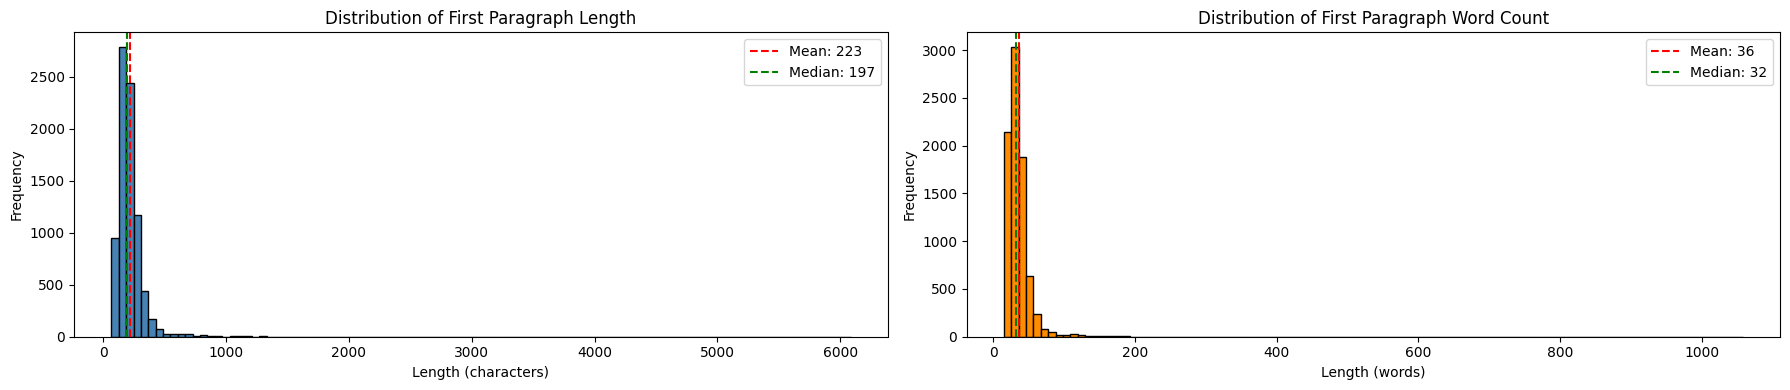

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# --- Plot 1 : char_count ---
axes[0].hist(df["char_count"], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title("Distribution of First Paragraph Length")
axes[0].set_xlabel("Length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["char_count"].mean(),   color='red',   linestyle='--', label=f'Mean: {df["char_count"].mean():.0f}')
axes[0].axvline(df["char_count"].median(), color='green', linestyle='--', label=f'Median: {df["char_count"].median():.0f}')
axes[0].legend()

# --- Plot 2 : word_count ---
axes[1].hist(df["word_count"], bins=100, color='darkorange', edgecolor='black')
axes[1].set_title("Distribution of First Paragraph Word Count")
axes[1].set_xlabel("Length (words)")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df["word_count"].mean(),   color='red',   linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[1].axvline(df["word_count"].median(), color='green', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [163]:
# The data is right-skewed (many short texts, few very long ones)

# Compute quartiles
Q1 = df["char_count"].quantile(0.25)
Q3 = df["char_count"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(df)

df = df[(df["char_count"] >= lower_bound) &
        (df["char_count"] <= upper_bound)]

after = len(df)

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

print(f"Before: {before}")
print(f"After:  {after}")
print(f"Removed: {before - after}")

Q1: 156.00
Q3: 248.00
IQR: 92.00
Lower bound: 18.00
Upper bound: 386.00
Before: 8223
After:  7863
Removed: 360


In [164]:
locations = set()

try:
    with open("datasets/reference/moroccan_cities_regions.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    for region in data["regions"]["data"]:
        for lang in ["ar", "fr", "en"]:
            locations.add(region["names"][lang].strip())
    for city in data["cities"]["data"]:
        for lang in ["ar", "fr", "en"]:
            locations.add(city["names"][lang].strip())
except Exception as e:
    print(f"Error : {e}")

try:
    countries_capitals = pd.read_csv("datasets/reference/countries_capitals.csv")
    for col in countries_capitals.columns:
        locations.update(countries_capitals[col].dropna().str.strip().tolist())
except Exception as e:
    print(f"Error : {e}")

df["has_location"]   = df["first_paragraph"].apply(lambda x: has_city(x, locations))

In [165]:
try:
    morrocan_names = pd.read_csv("datasets/reference/moroccan_names.csv")
    df["has_person"]   = df["first_paragraph"].apply(lambda x: has_person(x, morrocan_names["names"]))
except Exception as e:
    print(f"Error : {e}")

In [166]:
df.head(50)

,title,category,content,first_paragraph,char_count,word_count,code_switching,has_date,has_location,has_person
0,استعدادا للمونديال.. حموشي عين مسؤولين أمنيين ...,آش واقع,أشر المدير العام للأمن الوطني، عبد اللطيف حموش...,أشر المدير العام للأمن الوطني، عبد اللطيف حموش...,198,30,0,0,0,1
1,قرار محكمة العدل الاوربية. وزير خارجية الصبليو...,آش واقع,أعرب وزير الشؤون الخارجية الاسباني، خوسي مانوي...,أعرب وزير الشؤون الخارجية الاسباني، خوسي مانوي...,283,41,0,0,1,1
2,تحديد مواعيد مؤجلات الرجا وليفار وبركان وماتشا...,كود سبور,حددت العصبة الوطنية لكرة القدم الاحترافية، موا...,حددت العصبة الوطنية لكرة القدم الاحترافية، موا...,139,22,0,0,0,0
3,الأرصاد الجوية: الصهد فهاد المناطق والغيام فال...,آش واقع,توقعات المديرية العامة للأرصاد الجوية، بالنسبة...,توقعات المديرية العامة للأرصاد الجوية، بالنسبة...,236,35,0,0,1,0
4,تقرير: نتنياهو باغي يعرض خطط جديدة لضرب إيران ...,جورنالات بلادي,تستعد إسرائيل لطرح ملف حساس على طاولة الرئيس ا...,تستعد إسرائيل لطرح ملف حساس على طاولة الرئيس ا...,386,63,0,0,1,1
5,المجلس الوطني لحقوق الإنسان طلق حملة وطنية لمن...,آش واقع,أطلق المجلس الوطني لحقوق الإنسان، يوم الأربعاء...,أطلق المجلس الوطني لحقوق الإنسان، يوم الأربعاء...,167,27,0,1,1,0
6,احتجاجات جيلZ.. واش وصلنا لحالة استثناء فالبلا...,آش واقع,الأحداث الأخيرة اللي عاشتها بلادنا، من احتجاجا...,الأحداث الأخيرة اللي عاشتها بلادنا، من احتجاجا...,260,41,1,0,0,1
7,مريكان سجلات أول إصابة بسلالة فرعية من جدري ال...,جورنالات بلادي,أكدت المراكز الأميركية للسيطرة على الأمراض وال...,أكدت المراكز الأميركية للسيطرة على الأمراض وال...,186,31,0,0,1,0
8,رشيد المرابطي حطم الرقم القياسي لأسطورة ماراطو...,كود سبور,ربح العداء المغربي رشيد المرابطيماراطون الرمال...,ربح العداء المغربي رشيد المرابطيماراطون الرمال...,132,22,0,0,1,1
9,فيديو كيجيب الرعدة.. رونالدو كيعوم غير بشورت و...,كود سبور,بينما يقضي النجم البرتغالي كريستيانو رونالدو، ...,بينما يقضي النجم البرتغالي كريستيانو رونالدو، ...,146,23,0,0,1,0


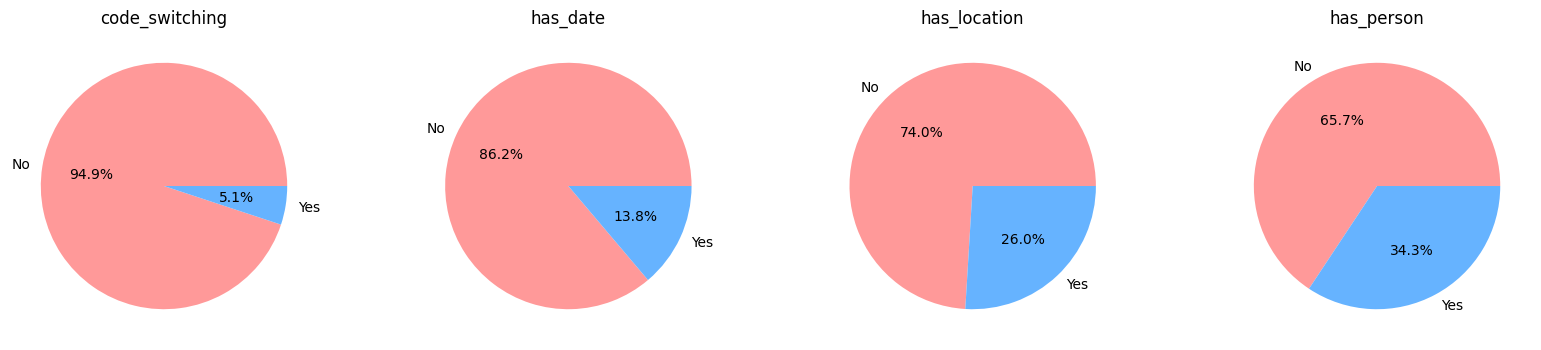

In [167]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, ["code_switching", "has_date", "has_location", "has_person"]):
    counts = df[col].value_counts()
    ax.pie(counts, labels=["No", "Yes"], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
    ax.set_title(col)

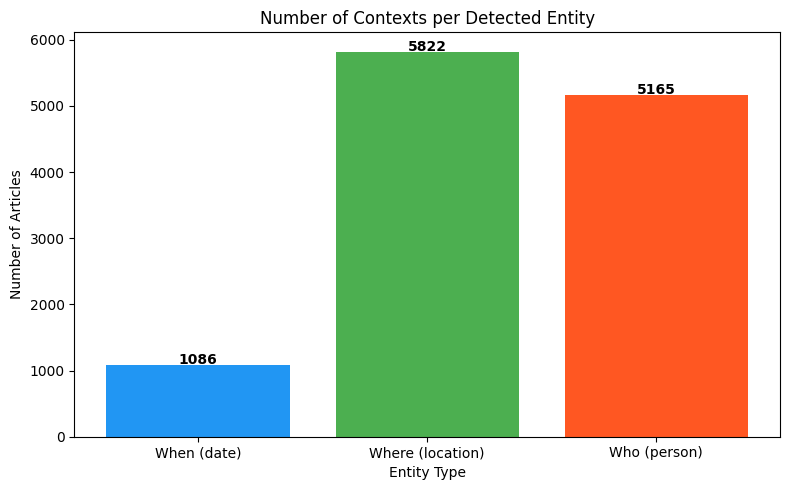

In [168]:
counts = {
    "When (date)"       : df["has_date"].sum(),
    "Where (location)"  : df["has_location"].sum(),
    "Who (person)"      : df["has_person"].sum(),
}

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values(), color=['#2196F3','#4CAF50','#FF5722'])
plt.title("Number of Contexts per Detected Entity")
plt.ylabel("Number of Articles")
plt.xlabel("Entity Type")

for i, (key, val) in enumerate(counts.items()):
    plt.text(i, val + 10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [169]:
df.to_csv("datasets/processed/goud_preprocessed_V1.csv", index=False, encoding="utf-8")